In [1]:
from pycorr import TwoPointCorrelationFunction
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import fitsio
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from CountsinCylinders import *

### SV3 Data ###

In [8]:
Abacus_elg = TwoPointCorrelationFunction.load("corrfunc/Abacus_ELGs.npy")
Abacus_lrg = TwoPointCorrelationFunction.load("corrfunc/Abacus_LRGs.npy")
SV3_elg = TwoPointCorrelationFunction.load("corrfunc/SV3_ELGs.npy")
SV3_lrg = TwoPointCorrelationFunction.load("corrfunc/SV3_LRGs.npy")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'Two-Point Correlation function in Abacus mocks (blue) and SV3 (orange), ELGs')

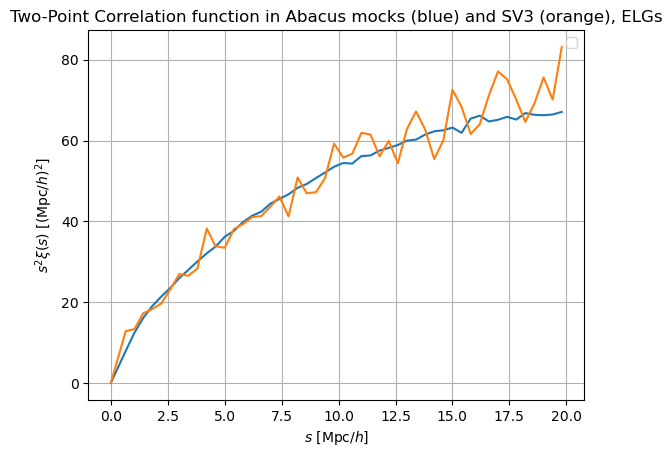

In [9]:
fig,ax=plt.subplots()
Abacus_elg.plot(ax=ax,label='Abacus')
SV3_elg.plot(ax=ax,label = "SV3")
ax.legend()
ax.set_title("Two-Point Correlation function in Abacus mocks (blue) and SV3 (orange), ELGs")

Text(0.5, 1.0, 'Two-Point Correlation function in Abacus mocks (blue) and SV3 (orange), LRGs')

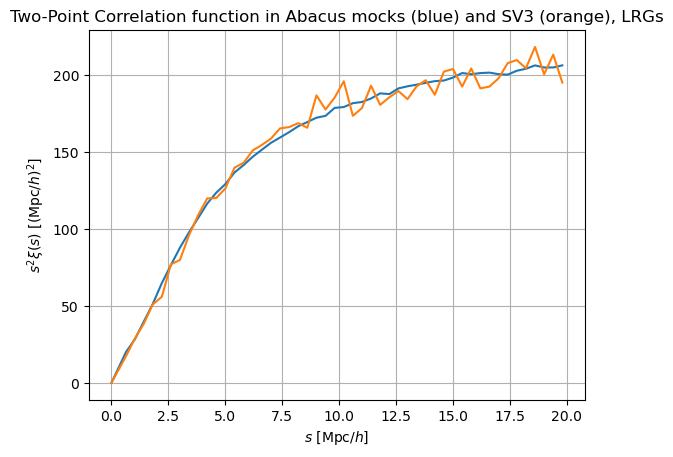

In [15]:
fig,ax=plt.subplots()
Abacus_lrg.plot(ax=ax,label = "Abacus")
SV3_lrg.plot(ax=ax)
ax.set_title("Two-Point Correlation function in Abacus mocks (blue) and SV3 (orange), LRGs")

Idea: check rp_pi

## rp_pi ##

In [29]:
Abacus_elg = TwoPointCorrelationFunction.load("corrfunc/Abacus_ELGs_rppi_1.npy")
Abacus_lrg = TwoPointCorrelationFunction.load("corrfunc/Abacus_LRGs_rppi_1.npy")
SV3_elg = TwoPointCorrelationFunction.load("corrfunc/SV3_ELGs_rppi_1.npy")
SV3_lrg = TwoPointCorrelationFunction.load("corrfunc/SV3_LRGs_rppi_1.npy")
SV3_elg_weighted = TwoPointCorrelationFunction.load("corrfunc/SV3_ELGs_rppi_weighted.npy")
SV3_lrg_weighted = TwoPointCorrelationFunction.load("corrfunc/SV3_LRGs_rppi_weighted.npy")

In [30]:
print(abelgcorr)
print(sv3elgcorr_w)

NameError: name 'abelgcorr' is not defined

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

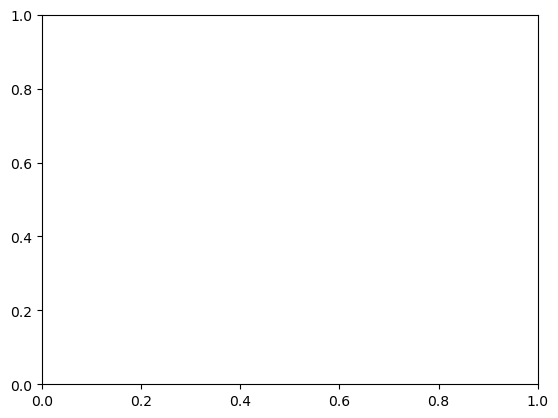

In [31]:
abelgcorr = Abacus_elg.get_corr()
sv3elgcorr_w = SV3_elg_weighted.get_corr()

plt.plot(np.arange(1,11),np.transpose(abelgcorr)[0])
plt.plot(np.arange(1,11),np.transpose(sv3elgcorr_w)[0])
plt.title("ELG Two-Point Correlation Function in Abacus and SV3")
plt.xlabel("$r_p$")
plt.ylabel(r"$\xi (r_p)$")

In [32]:
sv3elgros = []
sv3lrgros = []
sv3elgros_w = []
sv3lrgros_w = []
elg_rr = []
lrg_rr = []
lrg_dd = []
elg_dd = []
lrg_dr = []
elg_dr = []
elg_est2 = []
lrg_est2 = []
for i in range(20):
    elg = TwoPointCorrelationFunction.load("corrfunc/SV3_ELGs_rppi_ros_1"+str(i)+".npy")
    lrg = TwoPointCorrelationFunction.load("corrfunc/SV3_LRGs_rppi_ros_1"+str(i)+".npy")
    elg_w = TwoPointCorrelationFunction.load("corrfunc/SV3_ELGs_rppi_ros_weighted"+str(i)+".npy")
    lrg_w = TwoPointCorrelationFunction.load("corrfunc/SV3_LRGs_rppi_ros_weighted_"+str(i)+".npy")
    #print("rosette ",i)
    elg_rr.append(elg.R1R2.wcounts)
    lrg_rr.append(lrg.R1R2.wcounts)
    elg_dd.append(elg.D1D2.wcounts)
    lrg_dd.append(lrg.D1D2.wcounts)
    elg_dr.append(elg.D1R2.wcounts)
    lrg_dr.append(lrg.D1R2.wcounts)
    elg_est2.append((elg.D1D2.wcounts-elg.D1R2.wcounts)/elg.R1R2.wcounts)
    lrg_est2.append((lrg.D1D2.wcounts-lrg.D1R2.wcounts)/lrg.R1R2.wcounts)
    sv3elgros.append(elg.corr[0][0])
    sv3lrgros.append(lrg.corr[0][0])
    sv3elgros_w.append(elg_w.corr[0][0])
    sv3lrgros_w.append(lrg_w.corr[0][0])

In [33]:
abelgcorr = Abacus_elg.get_corr()
ablrgcorr = Abacus_lrg.get_corr()
sv3elgcorr = SV3_elg.get_corr()
sv3lrgcorr = SV3_lrg.get_corr()
sv3elgcorr_w = SV3_elg_weighted.get_corr()
sv3lrgcorr_w = SV3_lrg_weighted.get_corr()

In [34]:
print("Landy-Szalay Estimate of 2PCF")
print("Abacus ELGs:")
print(abelgcorr[0][0])
print("SV3 ELGs (Standard Error):")
print(sv3elgcorr[0][0], "+-",np.std(sv3elgros)/np.sqrt(20))
#print(sv3elgcorr[0][1], "+-",np.std(np.transpose(sv3elgros)[1])/np.sqrt(20))
print("SV3 ELGs, weighted:")
print(sv3elgcorr_w[0][0], "+-",np.std(sv3elgros_w)/np.sqrt(20))
print("Abacus LRGs:")
print(ablrgcorr[0][0])
print("SV3 LRGs (Standard Error):")
print(sv3lrgcorr[0][0], "+-",np.std(sv3lrgros)/np.sqrt(20))
print("SV3 LRGs, Weighted:")
print(sv3lrgcorr_w[0][0], "+-",np.std(sv3lrgros_w)/np.sqrt(20))
#print(sv3lrgcorr)#[0][1], "+-",np.std(np.transpose(sv3lrgros)[1])/np.sqrt(20))


print("\n(DD-DR)/RR Estimate")
print("Abacus ELGs:")
print((Abacus_elg.D1D2.wcounts-Abacus_elg.D1R2.wcounts)/Abacus_elg.R1R2.wcounts)
print("SV3 ELGs (Standard Error):")
print((SV3_elg.D1D2.wcounts-SV3_elg.D1R2.wcounts)/SV3_elg.R1R2.wcounts, "+-",np.std(elg_est2)/np.sqrt(20))
#print(sv3elgcorr[0][1], "+-",np.std(np.transpose(sv3elgros)[1])/np.sqrt(20))
print("Abacus LRGs:")
print((Abacus_lrg.D1D2.wcounts-Abacus_lrg.D1R2.wcounts)/Abacus_lrg.R1R2.wcounts)
print("SV3 LRGs (Standard Error):")
print((SV3_lrg.D1D2.wcounts-SV3_lrg.D1R2.wcounts)/SV3_lrg.R1R2.wcounts, "+-",np.std(lrg_est2)/np.sqrt(20))
#print(sv3lrgcorr)#[0][1], "+-",np.std(np.transpose(sv3lrgros)[1])/np.sqrt(20))

Landy-Szalay Estimate of 2PCF
Abacus ELGs:
1.8432615777907684
SV3 ELGs (Standard Error):
2.5240462429981836 +- 0.062432217398921235
SV3 ELGs, weighted:
1.7133727064504316 +- 0.032287285617751335
Abacus LRGs:
9.693839690134777
SV3 LRGs (Standard Error):
15.602898889556464 +- 0.48557821203482565
SV3 LRGs, Weighted:
9.779940924391031 +- 0.3198368923700296

(DD-DR)/RR Estimate
Abacus ELGs:
[[1.84388124]]
SV3 ELGs (Standard Error):
[[2.52451067]] +- 0.10486000072467944
Abacus LRGs:
[[9.69069743]]
SV3 LRGs (Standard Error):
[[15.60660416]] +- 0.8863587274758578


In [102]:
from CiCMoments import *

In [103]:
#SV3 counts around galaxies
sv3elg = Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_elg.csv")
sv3lrg = Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_lrg.csv")

sv3elg_ros = [sv3elg[(sv3elg['rosette'] == i)&(sv3elg['Z'] > 0.8)] for i in np.arange(1,21)]
sv3lrg_ros = [sv3lrg[(sv3lrg['rosette'] == i)&(sv3lrg['Z'] > 0.8)] for i in np.arange(1,21)]

In [104]:
SV3_elg_hist = CiCHistnZ(sv3elg_ros,elgname = "N_CiC")
SV3_lrg_hist = CiCHistnZ(sv3lrg_ros,lrgname = "N_CiC")

In [105]:
sv3_elg_momsimple = SV3_elg_hist.makeMomentTable(3, momentSimple,savesubsamples=True)
sv3_lrg_momsimple = SV3_lrg_hist.makeMomentTable(3, momentSimple,savesubsamples=True)

Text(0.5, 1.0, 'ELG 2PCF and Counts in Cylinders in SV3 Rosettes')

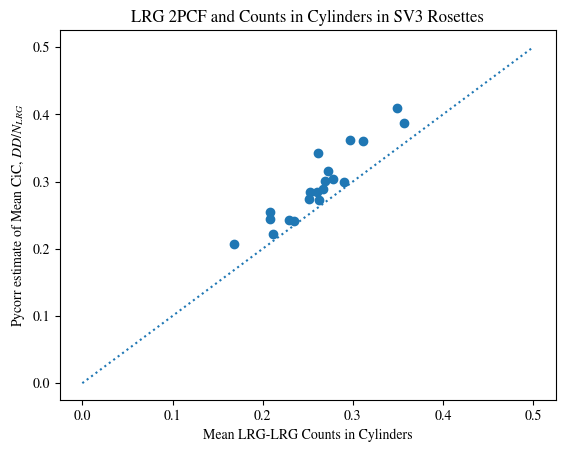

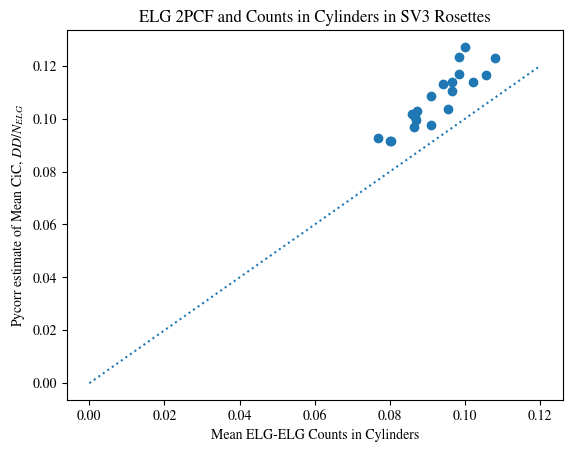

In [110]:
plt.scatter(sv3_lrg_momsimple[0]["SubsampleMoments"],lrg_CiCest)
plt.xlabel("Mean LRG-LRG Counts in Cylinders")
plt.ylabel(r"Pycorr estimate of Mean CiC, $DD/N_{LRG}$")
plt.title("LRG 2PCF and Counts in Cylinders in SV3 Rosettes")
plt.plot([0,0.5],[0,.5],linestyle='dotted',label = 'Equality')
plt.figure()
#with rosette-by-rosette weights elg2pcf_Ros = [2.1646452572039885, 2.3003359496868754, 2.459922823188088, 2.353285298642167, 3.012693101965009, 2.4673808805619175, 2.5194159421191116, 2.153617599822757, 3.0837472153799763, 2.4481011215873485, 2.175204429969685, 2.8286742714780893, 2.462385819685857, 2.5079080150819926, 2.6159414133833905, 3.1517164579873955, 2.5200425966111104, 2.745557285723653, 2.1603577373002283, 2.6864005011141177]
plt.scatter(sv3_elg_momsimple[3]["SubsampleMoments"],elg_CiCest)
plt.xlabel("Mean ELG-ELG Counts in Cylinders")
plt.ylabel(r"Pycorr estimate of Mean CiC, $DD/N_{ELG}$")
plt.plot([0,0.12],[0,.12],linestyle='dotted',label = 'Equality')
plt.title("ELG 2PCF and Counts in Cylinders in SV3 Rosettes")

In [111]:
print(sv3_lrg_momsimple)

ELG Order, LRG Order ...              SubsampleMoments             
-------------------- ... ------------------------------------------
              0 .. 1 ... 0.35694444444444445 .. 0.29694323144104806
              0 .. 2 ...   0.7138888888888889 .. 0.5393013100436681
              0 .. 3 ...   1.8694444444444445 .. 1.2074235807860263
              1 .. 0 ... 0.10138888888888889 .. 0.09606986899563319
              1 .. 1 ... 0.04236111111111111 .. 0.03384279475982533
              1 .. 2 ... 0.07708333333333334 .. 0.05786026200873363
              2 .. 0 ... 0.11666666666666667 .. 0.10480349344978165
              2 .. 1 ... 0.04513888888888889 .. 0.03384279475982533
              3 .. 0 ... 0.14722222222222223 .. 0.12882096069868995


## With no hole cleaning (trying to match as exactly as possible to 2pcf ##

In [112]:
#SV3 counts around galaxies
sv3elg = Table.read("datafiles/SV3_noclean_R1L40_elg.csv")
sv3lrg = Table.read("datafiles/SV3_noclean_R1L40_lrg.csv")

sv3elg_ros = [sv3elg[(sv3elg['rosette'] == i)&(sv3elg['Z'] > 0.8)] for i in np.arange(1,21)]
sv3lrg_ros = [sv3lrg[(sv3lrg['rosette'] == i)&(sv3lrg['Z'] > 0.8)] for i in np.arange(1,21)]

In [113]:
SV3_elg_hist = CiCHistnZ(sv3elg_ros,elgname = "N_CiC")
SV3_lrg_hist = CiCHistnZ(sv3lrg_ros,lrgname = "N_CiC")

In [114]:
sv3_elg_momsimple = SV3_elg_hist.makeMomentTable(3, momentSimple,savesubsamples=True)
sv3_lrg_momsimple = SV3_lrg_hist.makeMomentTable(3, momentSimple,savesubsamples=True)

In [115]:
elg_CiCest = [elg_dd[i]/len(sv3elg_ros[i]) for i in range(20)]
lrg_CiCest = [lrg_dd[i]/len(sv3lrg_ros[i]) for i in range(20)]

Text(0.5, 1.0, 'ELG 2PCF and Counts in Cylinders in SV3 Rosettes')

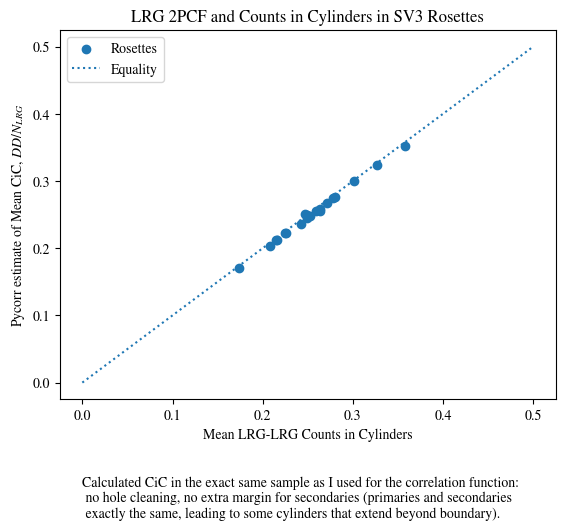

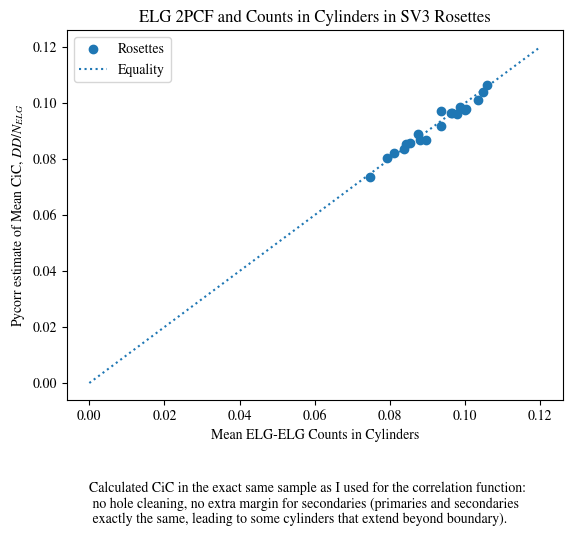

In [132]:
plt.scatter(sv3_lrg_momsimple[0]["SubsampleMoments"],lrg_CiCest,label = "Rosettes")
plt.xlabel("Mean LRG-LRG Counts in Cylinders")
plt.ylabel(r"Pycorr estimate of Mean CiC, $DD/N_{LRG}$")
plt.title("LRG 2PCF and Counts in Cylinders in SV3 Rosettes")
plt.plot([0,0.5],[0,.5],linestyle='dotted',label = 'Equality')
plt.legend()
plt.text(0,-0.2,"Calculated CiC in the exact same sample as I used for the correlation function: \n no hole cleaning, no extra margin for secondaries (primaries and secondaries \n exactly the same, leading to some cylinders that extend beyond boundary).")
plt.figure()
#with rosette-by-rosette weights elg2pcf_Ros = [2.1646452572039885, 2.3003359496868754, 2.459922823188088, 2.353285298642167, 3.012693101965009, 2.4673808805619175, 2.5194159421191116, 2.153617599822757, 3.0837472153799763, 2.4481011215873485, 2.175204429969685, 2.8286742714780893, 2.462385819685857, 2.5079080150819926, 2.6159414133833905, 3.1517164579873955, 2.5200425966111104, 2.745557285723653, 2.1603577373002283, 2.6864005011141177]
plt.scatter(sv3_elg_momsimple[3]["SubsampleMoments"],elg_CiCest,label = "Rosettes")
plt.xlabel("Mean ELG-ELG Counts in Cylinders")
plt.ylabel(r"Pycorr estimate of Mean CiC, $DD/N_{ELG}$")
plt.plot([0,0.12],[0,.12],linestyle='dotted',label = 'Equality')
plt.text(0,-0.05,"Calculated CiC in the exact same sample as I used for the correlation function: \n no hole cleaning, no extra margin for secondaries (primaries and secondaries \n exactly the same, leading to some cylinders that extend beyond boundary).")
plt.legend()
plt.title("ELG 2PCF and Counts in Cylinders in SV3 Rosettes")

In [35]:
#with PIP weights
#sv3_pip_elg = Table.read("/global/cfs/cdirs/desi/survey/catalogs/edav1/xi/sv3/rppi/xirppi_ELG_HIPnotqso_N_0.8_1.1_default_angular_bitwise_FKP_lin10_1_njack128_nran18_split20.txt",format="ascii.csv",skiplines=8)
sv3_pip_elg = TwoPointCorrelationFunction.load("/global/cfs/cdirs/desi/survey/catalogs/edav1/xi/sv3/rppi/allcounts_ELG_HIPnotqso_S_0.8_1.1_default_angular_bitwise_FKP_lin_njack128_nran18_split20.npy")

In [42]:
elgselected = sv3_pip_elg.select((0,1),(0,14))
#elgrebinned = elgselected.rebin((1,14))

In [43]:
print(elgselected.edges)

[array([0., 1.]), array([ 0., 14.])]


In [44]:
#get correlation function
elgcorrpip = elgselected.get_corr()

In [59]:
print("Cylinder average of ELG 2pcf, 0 < r_p < 1 Mpc/h, -20 < pi < 20 Mpc/h")
print("Abacus:")
print(np.round(abelgcorr[0][0],3))
print("SV3, individual weights:")
print(np.round(sv3elgcorr_w[0][0],3), "+-",np.round(np.std(sv3elgros_w)/np.sqrt(20),3))

print("SV3, pairwise weights (not my calculation):")
print(np.round(elgcorrpip[0][0][0],3), "+-",np.round(np.sqrt(elgcorrpip[1][0][0]),3))

Cylinder average of ELG 2pcf, 0 < r_p < 1 Mpc/h, -20 < pi < 20 Mpc/h
Abacus:
1.843
SV3, individual weights:
1.713 +- 0.032
SV3, pairwise weights (not my calculation):
1.745 +- 0.071


2.46

In [50]:
print(elgcorrpip[1])

[[0.00498371]]
